In [1]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import pickle
from PIL import Image
import imageio
import pydicom
import SimpleITK as sitk

In [2]:
def load_npy(file_path: str):
    return np.load(file_path)

def load_npz(file_path: str):
    data = np.load(file_path)
    return data

def load_pickle(file_path: str):
    with open(file_path, "rb") as f:
        data = pickle.load(f) 
    return data

def load_nib(file_path: str):
    nii_data = nib.load(file_path)

    image_data = nii_data.get_fdata()
    return image_data

def save_nib(file_path: str, volume):
    ct_image = sitk.GetImageFromArray(volume)
    sitk.WriteImage(ct_image, file_path)

def load_dcom(file_path: str):
    return pydicom.dcmread(file_path)

def scale_image(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val - min_val == 0:
        return np.zeros_like(image, dtype=np.uint8)
    
    scaled_image = (image - min_val) / (max_val - min_val) * 255
    
    return scaled_image.astype(np.uint8)

def normalize_image(image):
    min_val = np.min(image)
    max_val = np.max(image)

    if max_val - min_val > 0:
        image = (image - min_val) / (max_val - min_val)

    return image

def lung_window_clip(array: np.ndarray, min_px: int = -1200, max_px: int = 800):
    clipped_array = array.copy()
    clipped_array[clipped_array > max_px] = max_px
    clipped_array[clipped_array < min_px] = min_px
    return clipped_array

def plot_images(array_HU, array_Lung, title1="HU", title2="Lung"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(array_HU, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis("off")  # Hide axis

    axes[1].imshow(array_Lung, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis("off")  # Hide axis

def numpy_to_gif(array, folder_path="/data/hpc/dqm/3D-SegClass-Medical/assets", folder_name: str = "image", case_name: str = "3", duration=100):
    folder_path = folder_path + "/" + folder_name
    
    if not os.path.exists(folder_path):
        os.makedirs(folder_path, exists_ok=True)
        
    save_path_x = f"{folder_path}/{case_name}_x.gif"
    # save_path_y = f"{folder_path}/{case_name}_y.gif"
    # save_path_z = f"{folder_path}/{case_name}_z.gif"
    print(save_path_x)
    frames_x = []
    # frames_y = []
    # frames_z = []
    
    for i in range(array.shape[0]):
        img_x = Image.fromarray(scale_image(array[i, :, :])) 
        frames_x.append(img_x)

    frames_x[0].save(save_path_x, save_all=True, append_images=frames_x[1:], duration=duration, loop=0)

def lung_window_clip_volume(pixel_array: np.ndarray, min_px: int = -1200, max_px: int = 800):
    clipped_array = []
    for arr in pixel_array:
        clipped = arr.copy()
        clipped[clipped > max_px] = max_px
        clipped[clipped < min_px] = min_px
        clipped_array.append(clipped)
        
    return np.stack(clipped_array, axis = 0)


In [5]:
a = load_npy("/data/hpc/dqm/3D-SegClass-Medical/data/Mask/LIDC-IDRI-0101/0101_MA001.npy") * 255

numpy_to_gif(a, case_name=f"0101_mask", folder_name="test")
a.shape

/data/hpc/dqm/3D-SegClass-Medical/assets/test/0101_mask_x.gif


(188, 256, 256)

In [5]:
from skimage import measure, morphology

def largest_label_volume(im, bg=-1):
    vals, counts = np.unique(im, return_counts=True)

    counts = counts[vals != bg]
    vals = vals[vals != bg]

    if len(counts) > 0:
        return vals[np.argmax(counts)]
    else:
        return None

def segment_lung_mask(image, fill_lung_structures=True): # include structures within the lung
    
    # not actually binary, but 1 and 2. 
    # 0 is treated as background, which we do not want
    binary_image = np.array(image > -320, dtype=np.int8)+1
    labels = measure.label(binary_image)
    
    # Pick the pixel in the very corner to determine which label is air.
    #   Improvement: Pick multiple background labels from around the patient
    #   More resistant to "trays" on which the patient lays cutting the air 
    #   around the person in half
    background_label = labels[0,0,0]
    
    #Fill the air around the person
    binary_image[background_label == labels] = 2
    
    
    # Method of filling the lung structures (that is superior to something like 
    # morphological closing)
    if fill_lung_structures:
        # For every slice we determine the largest solid structure
        for i, axial_slice in enumerate(binary_image):
            axial_slice = axial_slice - 1
            labeling = measure.label(axial_slice)
            l_max = largest_label_volume(labeling, bg=0)
            
            if l_max is not None: #This slice contains some lung
                binary_image[i][labeling != l_max] = 1

    
    binary_image -= 1 #Make the image actual binary
    binary_image = 1-binary_image # Invert it, lungs are now 1
    
    # Remove other air pockets insided body
    labels = measure.label(binary_image, background=0)
    l_max = largest_label_volume(labels, bg=0)
    if l_max is not None: # There are air pockets
        binary_image[labels != l_max] = 0
 
    return binary_image

In [38]:
from medpy.filter.smoothing import anisotropic_diffusion
from scipy.ndimage import median_filter
from skimage import measure, morphology
import scipy.ndimage as ndimage
from sklearn.cluster import KMeans

def make_lungmask(img):
    image = []
    for i in img:
        row_size = i.shape[0]
        col_size = i.shape[1]
        mean = np.mean(i)
        std = np.std(i)
        i = i - mean
        i = i / std
        
        # Find the average pixel value near the lungs
        # to renormalize washed out images
        middle = i[int(col_size / 5):int(col_size / 5 * 4), int(row_size / 5):int(row_size / 5 * 4)]
        mean = np.mean(middle)
        max = np.max(i)
        min = np.min(i)
        # To improve threshold finding, I'm moving the
        # underflow and overflow on the pixel spectrum
        i[i == max] = mean
        i[i == min] = mean
        image.append(i)
    
    final_image = np.stack(image, axis=0)
    
    binary_image = segment_lung_mask(img)
    
    print(binary_image.shape)
    
    return binary_image * final_image
    

In [39]:
segmentation_np_tensor = []
# for slice in range(291, a.shape[0]):
#     print(slice)
lung_np_array = a[291, :,:]
segmentation_np_array = make_lungmask(a)
# segmentation_np_tensor.append(segmentation_np_array)
# segmentation_np_tensor = np.stack(segmentation_np_tensor, axis=0)

(292, 360, 360)


In [4]:
case_name = "0081"
image_path = f"/data/hpc/dqm/3D-SegClass-Medical/data/Image/LIDC-IDRI-{case_name}/{case_name}_NI001.npy"
lung_path = f"/data/hpc/dqm/3D-SegClass-Medical/data/Lung_Segmentation/LIDC-IDRI-{case_name}/{case_name}_NI001.npy"
mask_path = f"/data/hpc/dqm/3D-SegClass-Medical/data/Mask/LIDC-IDRI-{case_name}/{case_name}_MA001.npy"

image = load_npy(image_path)
lung = load_npy(lung_path)
mask = load_npy(mask_path) * 255

print("Image, Lung, Mask Shape:", image.shape, lung.shape, mask.shape)
print("Image, Lung, Mask Max:", image.max(), lung.max(), mask.max())
print("Image, Lung, Mask Min:", image.min(), lung.min(), mask.min())

# Convert 3D volume to LIDC Gif
numpy_to_gif(image, case_name=f"{case_name}_image", folder_name="test")
numpy_to_gif(lung, case_name=f"{case_name}_lung", folder_name="test")
numpy_to_gif(mask, case_name=f"{case_name}_mask", folder_name="test")

Image, Lung, Mask Shape: (188, 256, 256) (188, 256, 256) (188, 256, 256)
Image, Lung, Mask Max: 1.0 5.716349632367239 255
Image, Lung, Mask Min: 0.0 -0.8406698896769271 0
/data/hpc/dqm/3D-SegClass-Medical/assets/test/0081_image_x.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/test/0081_lung_x.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/test/0081_mask_x.gif


In [3]:
false_mul = "/data/hpc/dqm/3D-SegClass-Medical/assets/test/segmented_lung_fill_false_multiply.npy"
false_p = "/data/hpc/dqm/3D-SegClass-Medical/assets/test/segmented_lung_fill_false.npy"
true_mul = "/data/hpc/dqm/3D-SegClass-Medical/assets/test/segmented_lung_fill_true_multiply.npy"
true_p = "/data/hpc/dqm/3D-SegClass-Medical/assets/test/segmented_lung_fill_true.npy"

false_mul = load_npy(false_mul)
false_p = load_npy(false_p) * 255
true_mul = load_npy(true_mul)
true_p = load_npy(true_p) * 255

print(false_mul.shape, false_p.shape, true_mul.shape, true_p.shape)
print(false_mul.max(), false_p.max(), true_mul.max(), true_p.max())
print(false_mul.min(), false_p.min(), true_mul.min(), true_p.min())

# Convert 3D volume to LIDC Gif
numpy_to_gif(false_mul, case_name=f"false_mul", folder_name="test")
numpy_to_gif(false_p, case_name=f"false_p", folder_name="test")
numpy_to_gif(true_mul, case_name=f"true_mul", folder_name="test")
numpy_to_gif(true_p, case_name=f"true_p", folder_name="test")


(320, 380, 380) (320, 380, 380) (320, 380, 380) (320, 380, 380)
0 255 446 255
-1090 0 -1090 0
/data/hpc/dqm/3D-SegClass-Medical/assets/test/false_mul_x.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/test/false_p_x.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/test/true_mul_x.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/test/true_p_x.gif


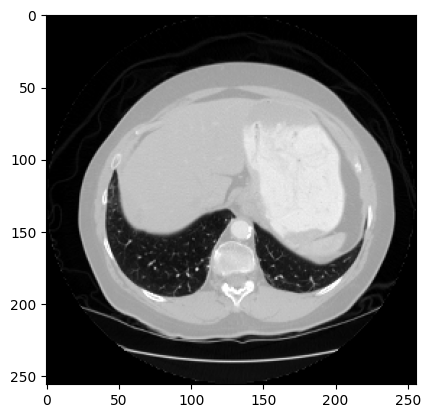

In [4]:
plt.imshow(normalize_image(a[0,:,:]), cmap="gray")

In [5]:
a = load_dcom("/data/hpc/dqm/data/LIDC-IDRI/LIDC-IDRI-0012/01-01-2000-NA-NA-50667/3000561.000000-NA-57842/1-012.dcm")

In [6]:
a

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 206
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.6279.6001.615106053010059882494714435596
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002,0013) Implementation Version Name         SH: '0.5'
(0002,0016) Source Application Entity Title     AE: 'POSDA'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.14519.5.2.1.6279.6001.61510605301005988

In [4]:
slice_thickness = np.abs(a.ImagePositionPatient[2] - b.ImagePositionPatient[2])
slice_thickness

2.5

In [17]:
file_path = "/data/hpc/dqm/3D-SegClass-Medical/data/Image_Segmentation/LIDC-IDRI-0001/0001_NI001.npy"
pixel_array = load_npy(file_path)
print("Volume shape:", pixel_array.shape)
print("Max pixel:", pixel_array.max())
print("Min pixel:", pixel_array.min())

clipped_array = lung_window_clip_volume(pixel_array)
print("Clipped shape:", clipped_array.shape)
print("Clipped pixel:", clipped_array.max())
print("Clipped pixel:", clipped_array.min())

clipped_array_1000 = lung_window_clip_volume(pixel_array, min_px=-1000, max_px=400)
print("Clipped shape:", clipped_array_1000.shape)
print("Clipped pixel:", clipped_array_1000.max())
print("Clipped pixel:", clipped_array_1000.min())

Volume shape: (128, 512, 512)
Max pixel: 3071
Min pixel: -1024
Clipped shape: (128, 512, 512)
Clipped pixel: 800
Clipped pixel: -1024
Clipped shape: (128, 512, 512)
Clipped pixel: 400
Clipped pixel: -1000


In [85]:
mask_path = "/data/hpc/dqm/3D-SegClass-Medical/data/Mask/LIDC-IDRI-0462/0462_MA001.npy"

mask_array = load_npy(mask_path)

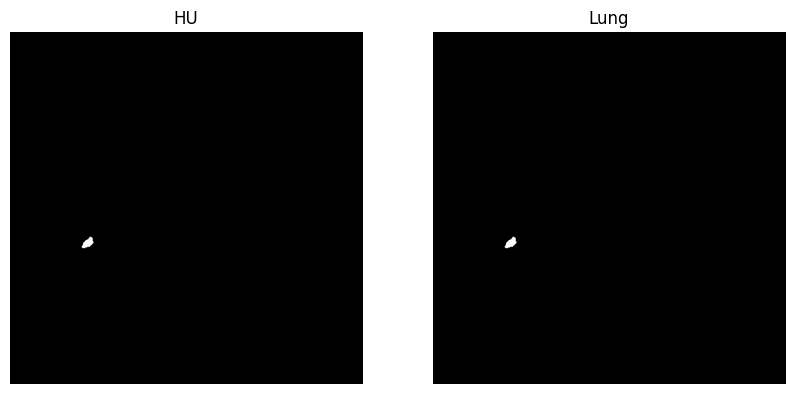

In [18]:
plot_images(mask_array[50, :, :] * 255, mask_array[50, :, :] * 255)


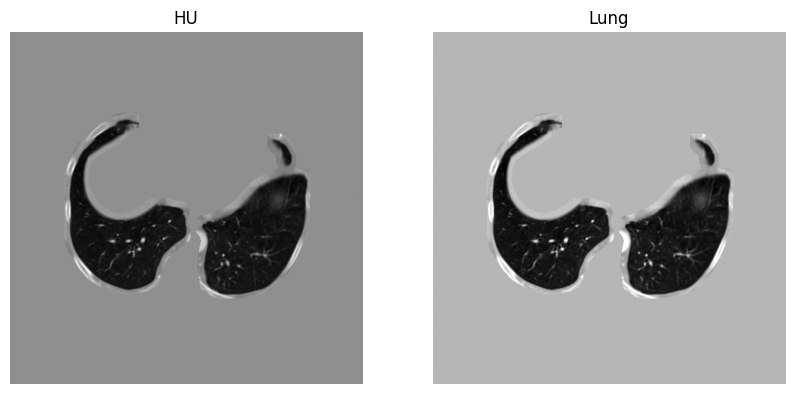

In [23]:
plot_images(normalize_image(lung_window_clip(clipped_array[50, :, :])), normalize_image(lung_window_clip(clipped_array_1000[50, :, :])))

In [26]:
normalize_image(clipped_array_1000[50, :, :])[0][0]

0.7142857142857143

In [4]:
pixel_array = load_npy("/data/hpc/dqm/3D-SegClass-Medical/data/Image_Segmentation/LIDC-IDRI-0126/0126_NI001.npy")

In [5]:
pixel_array.shape

(128, 512, 512)

In [6]:
numpy_to_gif(pixel_array, case_name="126", folder_name="lung")

# numpy_to_gif(clipped_array_1000, case_name="1_lung", folder_name="lung")

/data/hpc/dqm/3D-SegClass-Medical/assets/lung/126_x.gif


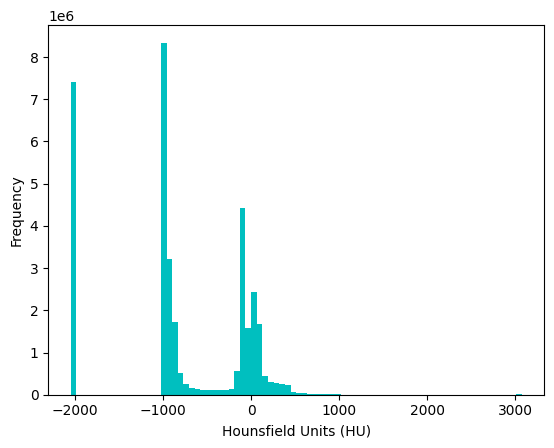

In [20]:
plt.hist(pixel_array.flatten(), bins=80, color='c')
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Convert 3D volume to LIDC Gif
numpy_to_gif(pixel_array, case_name="404_HU")

# Convert 3D clipped volume to LIDC Gif
numpy_to_gif(clipped_array, case_name="404_HU_clipped")


/data/hpc/dqm/3D-SegClass-Medical/assets/image/404_HU_x.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/image/404_HU_clipped_x.gif


In [5]:
file_path = "/data/hpc/dqm/3D-SegClass-Medical/data/Mask/LIDC-IDRI-0434/0434_MA001.npy"
pixel_array = load_npy(file_path)
print("Volume shape:", pixel_array.shape)
print("Max pixel:", pixel_array.max())
print("Min pixel:", pixel_array.min())

# Convert 3D mask
numpy_to_gif(pixel_array * 255, case_name="404_HU", folder_name="mask")

Volume shape: (128, 512, 512)
Max pixel: 1
Min pixel: 0
/data/hpc/dqm/3D-SegClass-Medical/assets/mask/404_HU_x.gif


1057
-2048


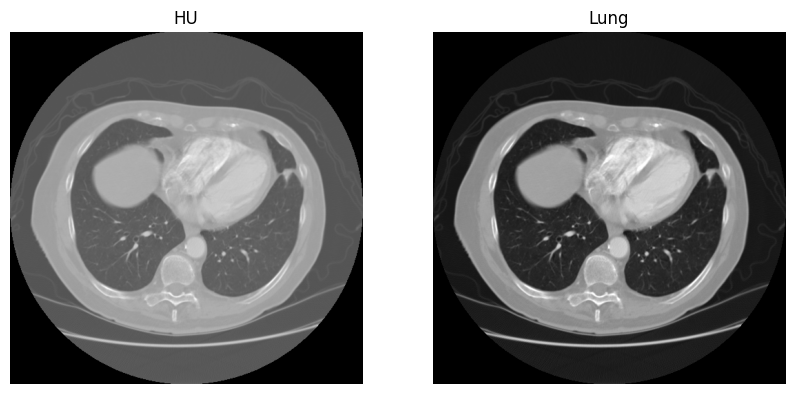

In [ ]:
array_HU = pixel_array[55, :, :]
print(array_HU.max())
print(array_HU.min())
array_Lung = normalize_image(lung_window_clip(array_HU))

plot_images(array_HU, array_Lung)

LIDC: 1209
LIDC: -2048
Max pixel: 1209.0
Min pixel: -2048.0
Max pixel: 2233
Min pixel: -1024


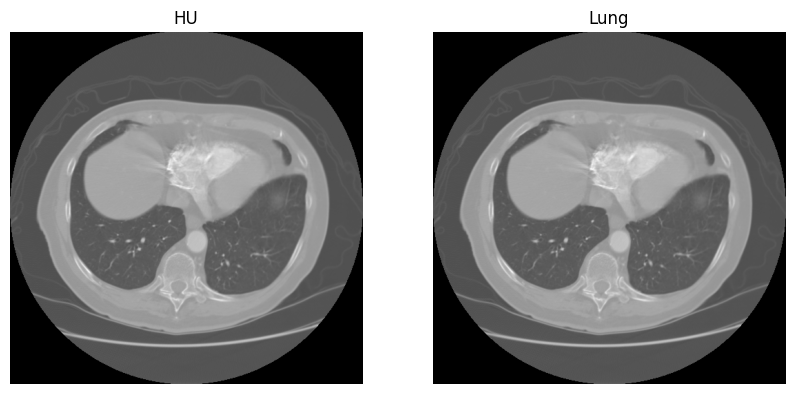

In [12]:
dicom = load_dcom('/data/hpc/dqm/data/LIDC-IDRI/LIDC-IDRI-0001/01-01-2000-NA-NA-30178/3000566.000000-NA-03192/1-078.dcm')

arr_dcom = dicom.pixel_array * dicom.RescaleSlope + dicom.RescaleIntercept

# arr_dcom_lung = normalize_image(lung_window_clip(arr_dcom))
print("LIDC:", pixel_array[50, :, :].max())
print("LIDC:", pixel_array[50, :, :].min())

print("Max pixel:", arr_dcom.max())
print("Min pixel:", arr_dcom.min())

print("Max pixel:", dicom.pixel_array.max())
print("Min pixel:", dicom.pixel_array.min())

plot_images(pixel_array[50, :, :], dicom.pixel_array)

In [62]:
test = pixel_array[:, :, 50] + 1024 - dicom.pixel_array
print(test.sum())

2051600


In [23]:
print(arr_dcom.max())
print(arr_dcom.min())

3071.0
-2048.0


In [30]:
print(dicom.pixel_array.max())
print(dicom.pixel_array.min())

4095
-1024


In [28]:

print(pixel_array.max())
print(pixel_array.min())

2047.0
-3072.0


In [75]:
dicom_data = load_dcom("/data/hpc/dqm/data/LIDC-IDRI/LIDC-IDRI-0001/01-01-2000-NA-NA-30178/3000566.000000-NA-03192/1-050.dcm")

In [76]:
dicom_data

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 206
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.6279.6001.106384226099293473735231576698
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002,0013) Implementation Version Name         SH: '0.5'
(0002,0016) Source Application Entity Title     AE: 'POSDA'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.14519.5.2.1.6279.6001.10638422609929347

In [77]:
arr = dicom_data.pixel_array

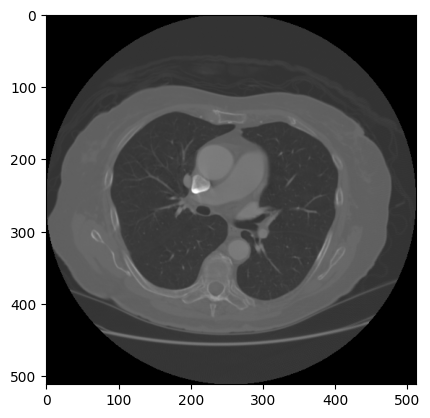

In [78]:
plt.imshow(arr, cmap="gray")

4095
-1024


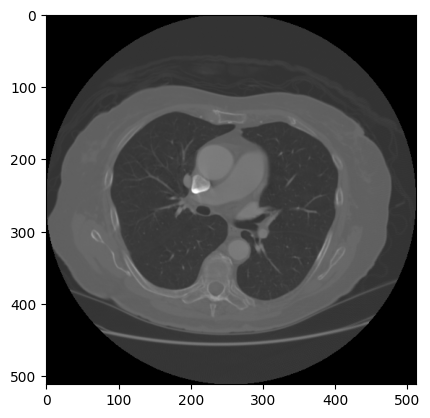

In [79]:
# arr[arr == -2000] = 0
plt.imshow(arr, cmap="gray")
print(arr.max())
print(arr.min())

3071.0
-2048.0


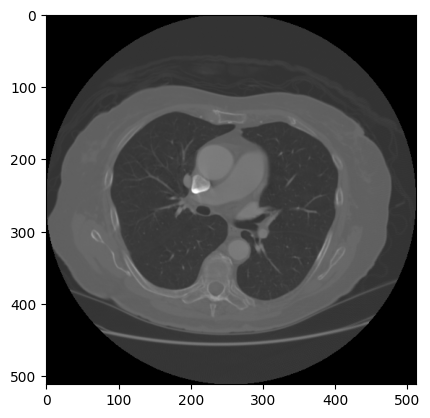

In [80]:
arr = arr * dicom_data.RescaleSlope + dicom_data.RescaleIntercept
plt.imshow(arr, cmap="gray")
print(arr.max())
print(arr.min())

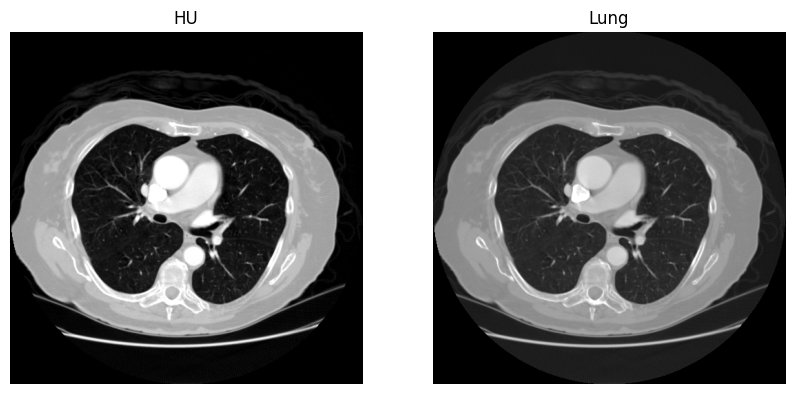

In [ ]:
plot_images(lung_window_clip_volume(arr, min_px=-1000, max_px=400), lung_window_clip_volume(arr, min_px=-1200, max_px=800))

In [ ]:
file_path = "/data/hpc/dqm/3D-SegClass-Medical/data/Image/LIDC-IDRI-0462/0462_NI001.npy"
pixel_array = load_npy(file_path)

pixel_array[pixel_array == -2000] = 0
clipped_array = lung_window_clip_volume(pixel_array)
clipped_array_1000 = lung_window_clip_volume(pixel_array, min_px=-1000, max_px=400)


Volume shape: (128, 512, 512)
Max pixel: 1548
Min pixel: -3024
Clipped shape: (128, 512, 512)
Clipped pixel: 800
Clipped pixel: -1200
Clipped shape: (128, 512, 512)
Clipped pixel: 400
Clipped pixel: -1000


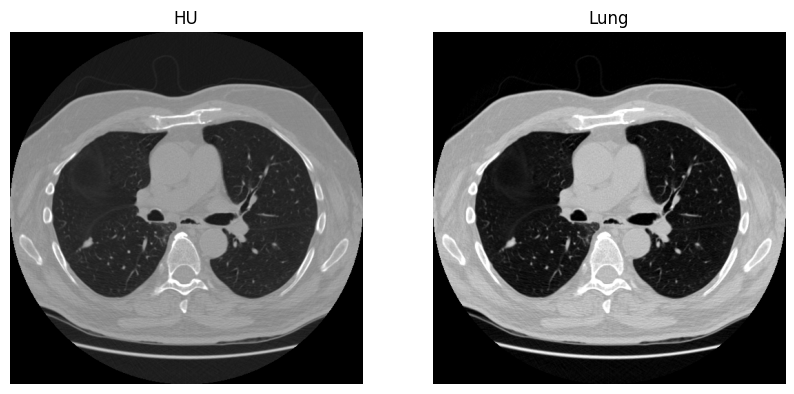

In [7]:
plot_images(clipped_array[50, :, :], clipped_array_1000[50, :, :])

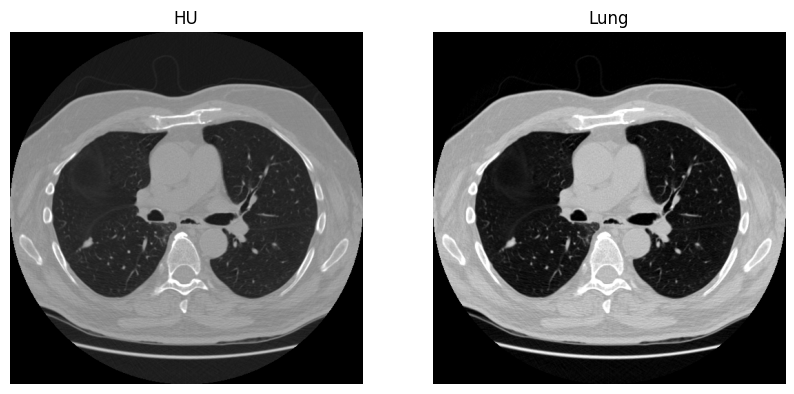

In [ ]:
file_path = "/data/hpc/dqm/3D-SegClass-Medical/data/Image/LIDC-IDRI-0462/0462_NI001.npy"
pixel_array = load_npy(file_path)

clipped_array = lung_window_clip_volume(pixel_array)
clipped_array_1000 = lung_window_clip_volume(pixel_array, min_px=-1000, max_px=400)
plot_images(clipped_array[50, :, :], clipped_array_1000[50, :, :])
